# Configuração Inicial

Este bloco de código realiza a preparação do ambiente e importa as bibliotecas necessárias para o projeto.

In [1]:
# ====================
# CONFIGURAÇÃO INICIAL
# ====================
import os
import zipfile
import shutil
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive

print("Configuração inicial concluída!")

Configuração inicial concluída!


# 1. Conexão Kaggle

Configura o acesso à API do Kaggle para baixar datasets diretamente no Colab:


In [2]:
# 1. CONEXÃO KAGGLE

# Configura a API do Kaggle usando o arquivo já enviado para o Colab
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/  # Puxa o arquivo da área de arquivos do Colab
!chmod 600 ~/.kaggle/kaggle.json

# 2. Baixar e Organizar Dados

- Baixa o dataset "dogs-vs-cats" da competição Kaggle
- Descompacta os arquivos ZIP:
  - Primeiro o arquivo principal (`dogs-vs-cats.zip`)
  - Depois o arquivo de treino (`train.zip`)
- Organiza a estrutura de pastas:
  - Cria diretórios separados para gatos (`cats`) e cães (`dogs`)
  - Move cada imagem para a pasta correspondente baseado no prefixo do nome do arquivo

In [3]:
# 2. BAIXAR E ORGANIZAR DADOS

# Baixa dataset da competição
!kaggle competitions download -c dogs-vs-cats

# Descompacta arquivos
with zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

with zipfile.ZipFile('/content/train.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/train')

# Organiza as pastas (código anterior)
os.makedirs('/content/train/cats', exist_ok=True)
os.makedirs('/content/train/dogs', exist_ok=True)

train_dir = '/content/train/train'
for filename in os.listdir(train_dir):
    if filename.startswith('cat'):
        shutil.move(os.path.join(train_dir, filename), '/content/train/cats/')
    elif filename.startswith('dog'):
        shutil.move(os.path.join(train_dir, filename), '/content/train/dogs/')

print("Dados baixados e organizados!")

Dados baixados e organizados!


# 3. Treinamento e Avaliação

Configuração do fluxo de dados para treinamento:
- **Pré-processamento**:
  - Redimensiona imagens para 150x150 pixels
  - Normaliza valores de pixel (0-255 → 0-1)
  - Aplica aumento de dados (data augmentation) com várias transformações

- **Divisão dos dados**:
  - 80% para treino / 20% para validação
  - Gera batches de 32 imagens cada

- **Geradores**:
  - `train_generator`: Fluxo de dados de treino com aumento de dados
  - `validation_generator`: Fluxo para validação (sem aumento de dados)

In [4]:
# 3. TREINAMENTO E AVALIAÇÃO

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 3 classes.
Found 5000 images belonging to 3 classes.


# 4. Modelo CNN

Arquitetura da rede neural convolucional:
- **Camadas convolucionais**:
  - 3 blocos Conv2D + MaxPooling2D (32, 64 e 128 filtros)
  - Função de ativação ReLU
  - Redução progressiva da dimensionalidade

- **Camadas densas**:
  - Camada flatten para converter features 2D → 1D
  - Camada densa com 512 neurônios + Dropout (50%) para regularização
  - Saída binária (sigmoid) para classificação gato/cachorro

- **Compilação**:
  - Otimizador Adam com learning rate 1e-4
  - Função de perda: binary_crossentropy
  - Métricas: acurácia e AUC (Area Under Curve)

In [5]:
# 4. MODELO CNN

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("Modelo CNN compilado!")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo CNN compilado!


# 5. Callbacks de Treinamento

Implementação de callbacks para otimizar o treinamento:
- **EarlyStopping**: Interrompe o treino se a val_loss não melhorar por 5 épocas consecutivas, restaurando os melhores pesos encontrados
- **ModelCheckpoint**: Salva automaticamente o modelo com melhor performance (menor val_loss) no arquivo `best_model.h5`

Estas técnicas previnem overfitting e garantem que sempre terá a melhor versão do modelo, mesmo que o treinamento continue por muitas épocas sem melhoras.

In [6]:
# 5. CALLBACKS

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_model.h5', monitor='val_loss', save_best_only=True)
]

print("Callbacks configurados!")

Callbacks configurados!


# 6. Treinamento do Modelo

Executa o treinamento da CNN utilizando os geradores de dados configurados anteriormente. Principais características:

- **15 épocas** de treinamento atingiram ~80% de acurácia, mais epócas podem chegar a valores maiores. (Mais tempo de treinamento)

In [7]:
# 6. TREINAMENTO

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5797 - auc: 0.6093 - loss: 0.6693

625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 285ms/step - accuracy: 0.5797 - auc: 0.6094 - loss: 0.6693 - val_accuracy: 0.6654 - val_auc: 0.7606 - val_loss: 0.5970
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.6850 - auc: 0.7468 - loss: 0.5932

625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 270ms/step - accuracy: 0.6851 - auc: 0.7468 - loss: 0.5932 - val_accuracy: 0.6918 - val_auc: 0.7802 - val_loss: 0.5785
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7060 - auc: 0.7794 - loss: 0.5606

625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 271ms/step - accuracy: 0.7060 - auc: 0.7794 - loss: 0.5606 - val_accuracy: 0.7316 - val_auc: 0.8154 - val_loss: 0.5325
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7238 - auc: 0.7999 - loss: 0.5408

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 275ms/step - accuracy: 0.7757 - auc: 0.8612 - loss: 0.4641 - val_accuracy: 0.7800 - val_auc: 0.8802 - val_loss: 0.4503
Epoch 9/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7890 - auc: 0.8715 - loss: 0.4492

625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 271ms/step - accuracy: 0.7890 - auc: 0.8715 - loss: 0.4492 - val_accuracy: 0.7928 - val_auc: 0.8741 - val_loss: 0.4459
Epoch 10/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7959 - auc: 0.8781 - loss: 0.4368

625/625 ━━━━━━━━━━━━━━━━━━━━ 171s 274ms/step - accuracy: 0.7959 - auc: 0.8781 - loss: 0.4368 - val_accuracy: 0.8024 - val_auc: 0.8861 - val_loss: 0.4296
Epoch 11/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7990 - auc: 0.8825 - loss: 0.4309

625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 267ms/step - accuracy: 0.7990 - auc: 0.8825 - loss: 0.4309 - val_accuracy: 0.8050 - val_auc: 0.8961 - val_loss: 0.4113
Epoch 12/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 268ms/step - accuracy: 0.8006 - auc: 0.8812 - loss: 0.4339 - val_accuracy: 0.8002 - val_auc: 0.8970 - val_loss: 0.4237
Epoch 13/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 283ms/step - accuracy: 0.8087 - auc: 0.8937 - loss: 0.4114 - val_accuracy: 0.8050 - val_auc: 0.9021 - val_loss: 0.4164
Epoch 14/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8105 - auc: 0.8960 - loss: 0.4071

625/625 ━━━━━━━━━━━━━━━━━━━━ 183s 292ms/step - accuracy: 0.8105 - auc: 0.8960 - loss: 0.4071 - val_accuracy: 0.8260 - val_auc: 0.9055 - val_loss: 0.3947
Epoch 15/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 268ms/step - accuracy: 0.8122 - auc: 0.8944 - loss: 0.4110 - val_accuracy: 0.8218 - val_auc: 0.9047 - val_loss: 0.3979


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 7. Avaliação do Modelo

Processo final de validação do modelo treinado:

- **Métricas calculadas**:
  - `val_loss`: Perda (erro) nos dados de validação
  - `val_acc`: Acurácia percentual (porcentagem de acertos)
  - `val_auc`: Área sob a curva ROC (mede qualidade da classificação)

Esta etapa crucial verifica o desempenho real do modelo com dados não vistos durante o treinamento, indicando sua capacidade de generalização.

In [ ]:
# 7. AVALIAÇÃO

val_loss, val_acc, val_auc = model.evaluate(validation_generator)
print(f"\nResultados Finais:")
print(f"- Acurácia na Validação: {val_acc:.2%}")
print(f"- AUC na Validação: {val_auc:.2%}")

# 8. Salvamento do Modelo no Google Drive

Conecta o ambiente do Colab ao Google Drive, salva o arquivo no formato `.h5` (formato padrão do Keras)

   - Caminho típico: `/content/drive/MyDrive/Colab_Models/`
   - Nome do arquivo: `cats_vs_dogs_final.h5`

In [10]:
# 8. SALVAR MODELO NO DRIVE

drive.mount('/content/drive')
model.save('/content/drive/MyDrive/Colab_Models/cats_vs_dogs_final.h5')
print("Modelo salvo no Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo salvo no Google Drive!


# 9. Predição a partir de Arquivo ZIP

Função especializada para testar o modelo diretamente com o dataset original do Kaggle:

- Processa imagens **diretamente do arquivo ZIP** sem necessidade de extração e exibe visualizações comparativas com

🔍 Encontradas 12500 imagens no arquivo ZIP
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step


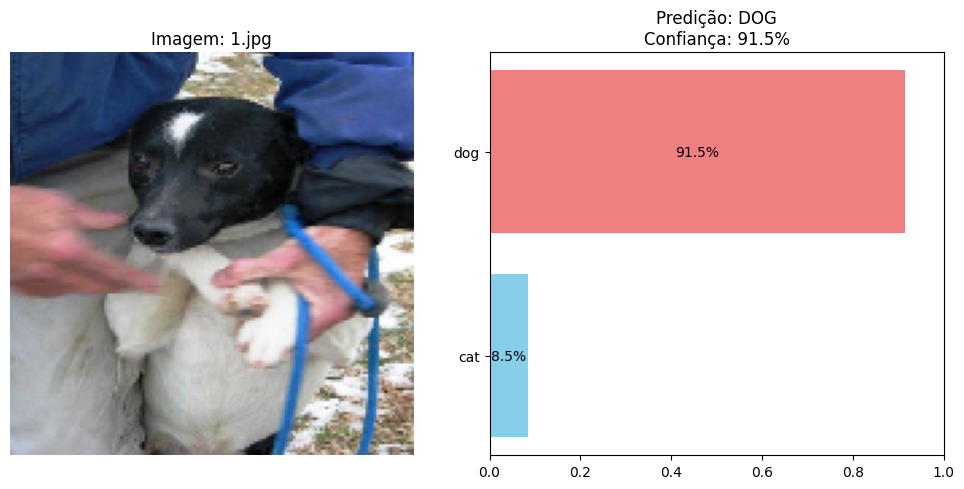

📊 Probabilidade bruta: 0.9150
──────────────────────────────────────────────────
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


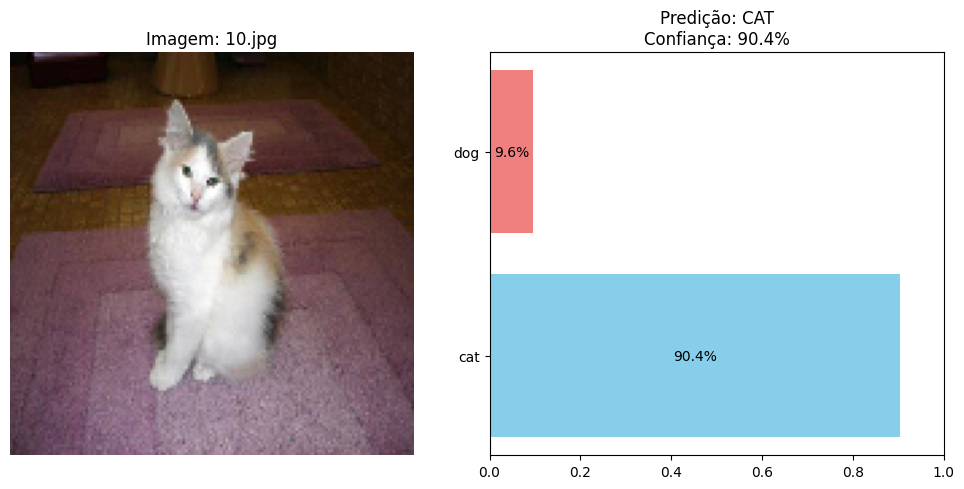

📊 Probabilidade bruta: 0.0962
──────────────────────────────────────────────────
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


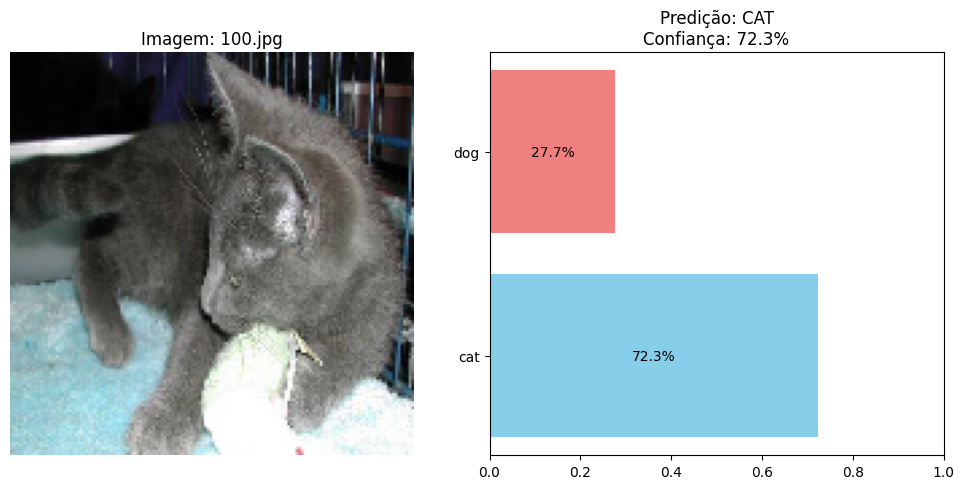

📊 Probabilidade bruta: 0.2774
──────────────────────────────────────────────────
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


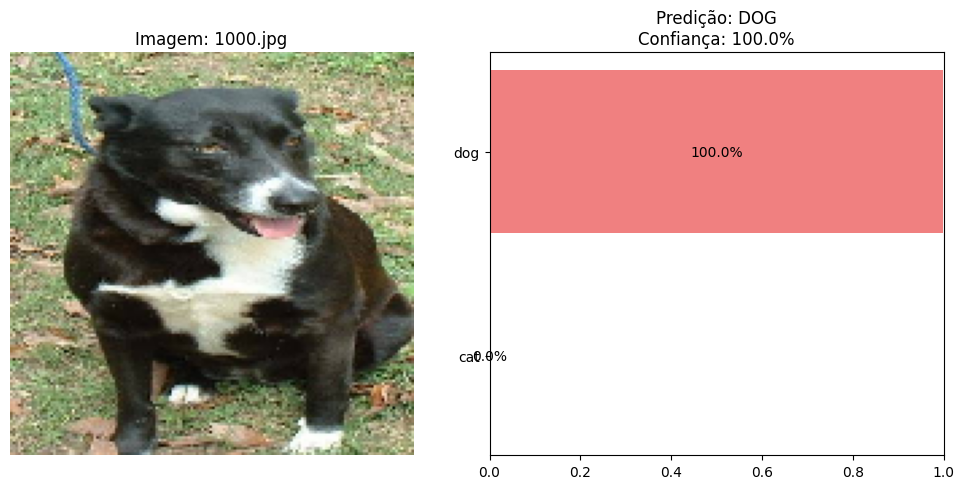

📊 Probabilidade bruta: 0.9996
──────────────────────────────────────────────────
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


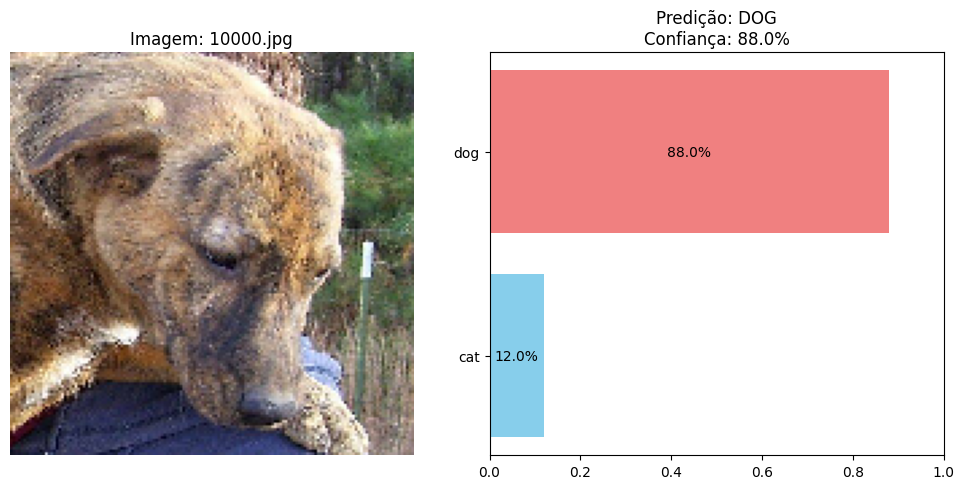

📊 Probabilidade bruta: 0.8799
──────────────────────────────────────────────────


In [11]:
import numpy as np
import zipfile
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from IPython.display import display
import io

def predict_from_zip(model, zip_path, num_images=5, target_size=(150, 150)):
    """
    Faz predições diretamente de um arquivo ZIP do Kaggle

    Args:
        model: Modelo Keras treinado
        zip_path: Caminho para o ZIP (ex: '/content/test1.zip')
        num_images: Número de imagens para exibir
        target_size: Tamanho esperado pelo modelo
    """
    # Verifica se o ZIP existe
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Arquivo ZIP não encontrado: {zip_path}")

    # Mapeamento de classes (ajuste conforme seu modelo)
    class_names = ['cat', 'dog']

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Filtra apenas imagens JPG/JPEG
        image_files = [f for f in zip_ref.namelist() if f.lower().endswith(('.jpg', '.jpeg'))]

        if not image_files:
            raise ValueError("Nenhuma imagem encontrada no ZIP")

        print(f"🔍 Encontradas {len(image_files)} imagens no arquivo ZIP")

        # Processa as imagens
        for i, img_file in enumerate(image_files[:num_images]):
            with zip_ref.open(img_file) as file:
                # Carrega a imagem diretamente do ZIP
                img_bytes = file.read()
                img = image.load_img(io.BytesIO(img_bytes), target_size=target_size)
                img_array = image.img_to_array(img) / 255.0
                img_array = np.expand_dims(img_array, axis=0)

                # Predição
                pred_prob = model.predict(img_array)[0][0]
                pred_class = 1 if pred_prob >= 0.5 else 0
                confidence = pred_prob if pred_class == 1 else (1 - pred_prob)

                # Exibição
                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.imshow(img)
                plt.title(f"Imagem: {img_file.split('/')[-1]}")
                plt.axis('off')

                plt.subplot(1, 2, 2)
                bars = plt.barh(class_names, [1-pred_prob, pred_prob], color=['skyblue', 'lightcoral'])
                plt.xlim(0, 1)
                plt.title(f'Predição: {class_names[pred_class].upper()}\nConfiança: {confidence:.1%}')

                for bar in bars:
                    width = bar.get_width()
                    plt.text(width/2, bar.get_y() + bar.get_height()/2,
                            f'{width:.1%}',
                            ha='center', va='center')

                plt.tight_layout()
                plt.show()

                print(f"📊 Probabilidade bruta: {pred_prob:.4f}")
                print("─" * 50)

# ===========================================
# EXECUÇÃO (usando o dataset oficial do Kaggle)
# ===========================================

# Certifique-se que o arquivo ZIP está no local correto
if os.path.exists('/content/test1.zip'):
    predict_from_zip(
        model=model,
        zip_path='/content/test1.zip',  # Arquivo ZIP original do Kaggle
        num_images=5,
        target_size=(150, 150)
    )
else:
    print("⚠️ Arquivo '/content/test1.zip' não encontrado. Faça o download primeiro:")
    print("!kaggle competitions download -c dogs-vs-cats")

# 10. Avaliação Detalhada do Modelo

Análise completa do desempenho do classificador:

- **1. Geração de Previsões**

- **2. Visualização da Matriz de Confusão**

- **3. Métricas de Classificação**

- **4. Acurácia Balanceada**


Found 5000 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 219ms/step


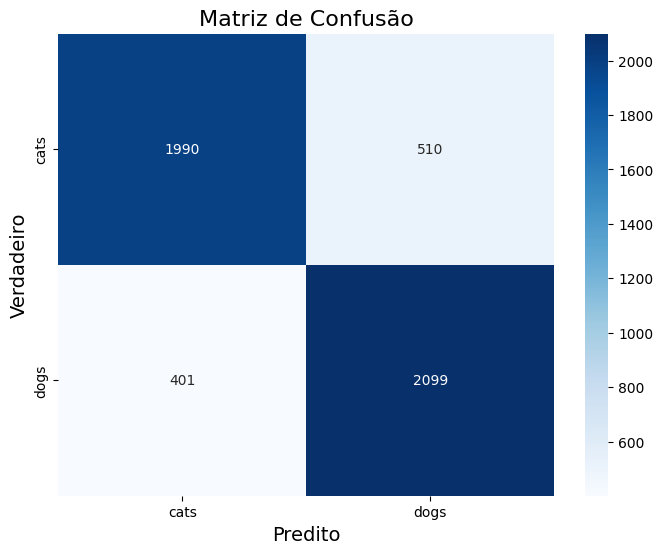


📊 Relatório de Classificação:
              precision    recall  f1-score   support

        cats     0.8323    0.7960    0.8137      2500
        dogs     0.8045    0.8396    0.8217      2500

    accuracy                         0.8178      5000
   macro avg     0.8184    0.8178    0.8177      5000
weighted avg     0.8184    0.8178    0.8177      5000


🔍 Acurácia Balanceada: 81.78%


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Gerar previsões para os dados de validação
val_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False  # Importante para manter a ordem dos rótulos
)

# Obter rótulos verdadeiros e previsões
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 2. Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

# Corrigindo a lista de nomes de classes:
class_names = ['cats', 'dogs']  # Define explicitamente as classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusão', fontsize=16)
plt.xlabel('Predito', fontsize=14)
plt.ylabel('Verdadeiro', fontsize=14)
plt.show()


# 3. Métricas Detalhadas
print("\n📊 Relatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 4. Cálculo de Acurácia Balanceada (importante para classes desbalanceadas)
balanced_acc = np.mean([cm[0,0]/(cm[0,0]+cm[0,1]),
                          cm[1,1]/(cm[1,0]+cm[1,1])])
print(f"\n🔍 Acurácia Balanceada: {balanced_acc:.2%}")